In [1]:
# Install and import libraries
!pip install tensorflow
!uv add tensorflow

Resolved 106 packages in 1.63s
 Downloaded keras
 Downloaded h5py
 Downloaded grpcio
 Downloaded libclang
 Downloaded tensorflow
Prepared 18 packages in 2m 24s
Uninstalled 1 package in 164ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 21 packages in 50.77s
 + absl-py==2.4.0
 + astunparse==1.6.3
 + flatbuffers==25.12.19
 + gast==0.7.0
 + google-pasta==0.2.0
 + grpcio==1.81.0
 + h5py==3.14.0
 + keras==3.14.1
 + libclang==18.1.1
 + markdown-it-py==4.2.0
 + mdurl==0.1.2
 + ml-dtypes==0.5.4
 + namex==0.1.0
 + opt-einsum==3.4.0
 + optree==0.19.1
 + rich==15.0.0
 - setuptools==65.5.0
 + setuptools==82.0.1
 + tensorflow==2.21.0
 + termcolor==3.3.0
 + wheel==0.47.0
 + wrapt==2.2.1


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [11]:
# Load SMS Spam dataset
data = pd.read_csv("spam.csv")
data.columns = ['label','message']

# Encode labels
data['label'] = data['label'].map({'ham':0, 'spam':1, 'jack': 2})

In [12]:
data

,label,message
0,0,"Hey, are we still meeting at 6?"
1,1,Congratulations! You have won a free lottery t...
2,0,Don't forget to bring the documents tomorrow.
3,1,Get cheap meds online now!!! Limited offer.
4,0,Can you send me the report by evening?
5,1,You won a $1000 gift card. Claim now!
6,0,Lunch at 1 pm?
7,1,Exclusive deal just for you. Buy now!


In [13]:
# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(data['message']) #134 3 3455 3455 675 --> vectors / tensors
sequences = tokenizer.texts_to_sequences(data['message'])
padded = pad_sequences(sequences, maxlen=100) #134 43 3455 34655 675 --> padded vectors / tensors

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded, data['label'], test_size=0.2, random_state=42)

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(5000, 64, input_length=100), # convert tensors --> embeddings
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)), # convert nueral network mappings 
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

e:\work\internship\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6667 - loss: 0.6434 - val_accuracy: 0.0000e+00 - val_loss: 0.8686
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6667 - loss: 0.6313 - val_accuracy: 0.0000e+00 - val_loss: 0.9282
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.6667 - loss: 0.6189 - val_accuracy: 0.0000e+00 - val_loss: 1.0102
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6667 - loss: 0.6078 - val_accuracy: 0.0000e+00 - val_loss: 1.1113
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6667 - loss: 0.6002 - val_accuracy: 0.0000e+00 - val_loss: 1.2038


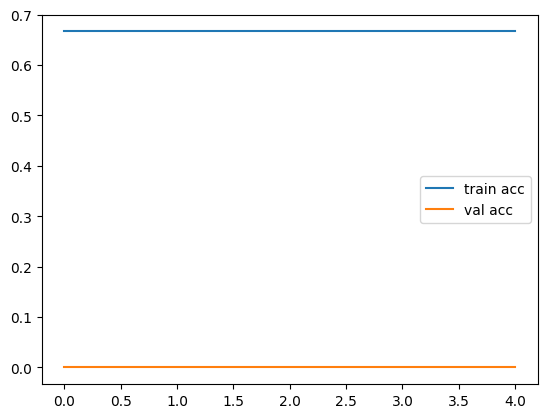

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
[[0 0]
 [2 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



e:\work\internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\work\internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\work\internship\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\work\internship\.venv\Lib\site-pa

In [17]:
# Accuracy and loss plots
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

# Confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [18]:
# Save model
model.save("spam_detection_model.h5")

# Example prediction
test_message = ["Congratulations! You won a free ticket"]
seq = tokenizer.texts_to_sequences(test_message)
padded_seq = pad_sequences(seq, maxlen=100)
print("Spam" if model.predict(padded_seq)[0][0] > 0.5 else "Ham")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Ham
